In [5]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Clean visual style
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

# Relative path from 'notebooks/' to 'data/raw/creditcard.csv'
DATA_PATH = os.path.join("..", "data", "raw", "creditcard.csv")
print("Environment and libraries ready!")

Environment and libraries ready!


In [6]:
df = pd.read_csv(DATA_PATH)
print(f"Dataset Shape: {df.shape[0]:,} rows, {df.shape[1]} columns")
df.head()

Dataset Shape: 284,807 rows, 31 columns


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


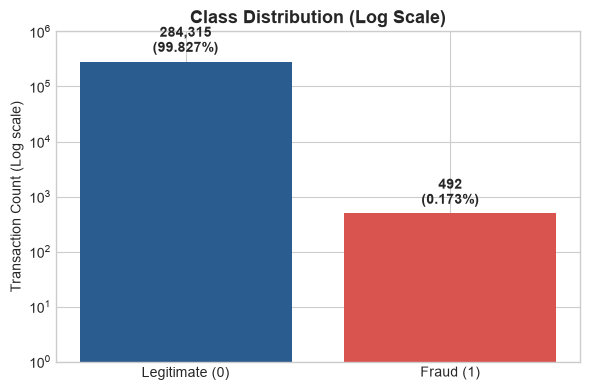

In [7]:
fig, ax = plt.subplots(figsize=(6, 4))
counts = df['Class'].value_counts()

ax.bar(['Legitimate (0)', 'Fraud (1)'], counts.values, color=['#2b5c8f', '#d9534f'])
ax.set_yscale('log')

for i, v in enumerate(counts.values):
    ax.text(i, v * 1.5, f"{v:,}\n({v/len(df)*100:.3f}%)", ha='center', fontweight='bold', fontsize=10)

plt.title("Class Distribution (Log Scale)", fontsize=13, fontweight='bold')
plt.ylabel("Transaction Count (Log scale)")
plt.ylim(1, 1e6)
plt.tight_layout()
plt.show()

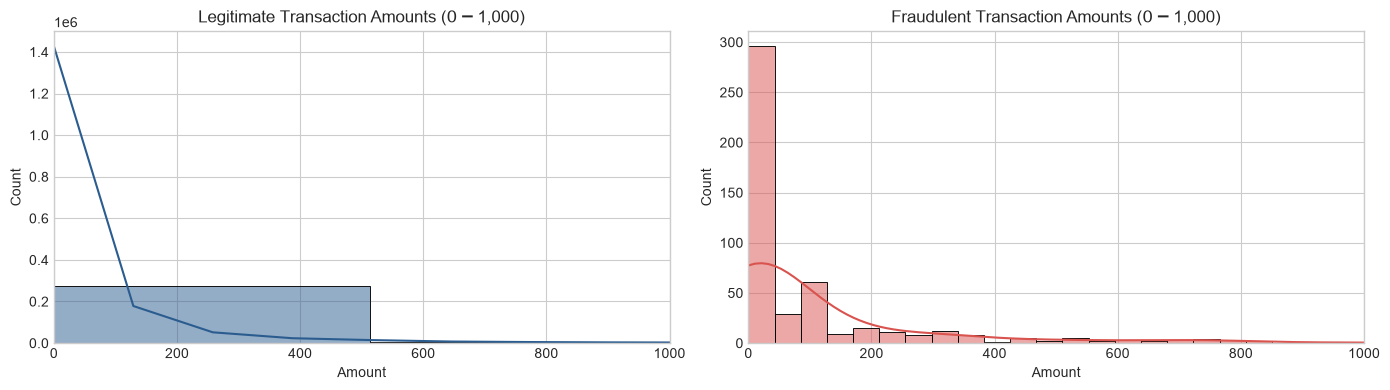

--- Legitimate Summary Stats ---
count    284315.00
mean         88.29
std         250.11
min           0.00
25%           5.65
50%          22.00
75%          77.05
max       25691.16
Name: Amount, dtype: float64

--- Fraudulent Summary Stats ---
count     492.00
mean      122.21
std       256.68
min         0.00
25%         1.00
50%         9.25
75%       105.89
max      2125.87
Name: Amount, dtype: float64


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Legitimate transactions
sns.histplot(df[df['Class'] == 0]['Amount'], bins=50, ax=axes[0], color='#2b5c8f', kde=True)
axes[0].set_title("Legitimate Transaction Amounts ($0 - $1,000)")
axes[0].set_xlim(0, 1000)

# Fraudulent transactions
sns.histplot(df[df['Class'] == 1]['Amount'], bins=50, ax=axes[1], color='#d9534f', kde=True)
axes[1].set_title("Fraudulent Transaction Amounts ($0 - $1,000)")
axes[1].set_xlim(0, 1000)

plt.tight_layout()
plt.show()

print("--- Legitimate Summary Stats ---")
print(df[df['Class'] == 0]['Amount'].describe().round(2))
print("\n--- Fraudulent Summary Stats ---")
print(df[df['Class'] == 1]['Amount'].describe().round(2))

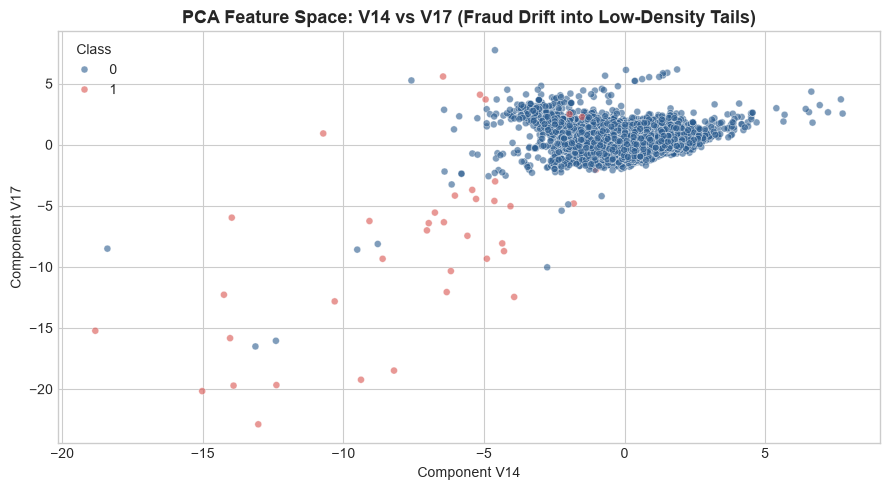

In [9]:
plt.figure(figsize=(9, 5))

# Subsample 25,000 rows so plotting stays instantaneous
sample_df = df.sample(25000, random_state=42)

sns.scatterplot(
    data=sample_df,
    x='V14', 
    y='V17', 
    hue='Class', 
    palette={0: '#2b5c8f', 1: '#d9534f'},
    alpha=0.6,
    s=25
)

plt.title("PCA Feature Space: V14 vs V17 (Fraud Drift into Low-Density Tails)", fontsize=13, fontweight='bold')
plt.xlabel("Component V14")
plt.ylabel("Component V17")
plt.tight_layout()
plt.show()

### Milestone 1 Key Findings & Justifications:
1. **Severe Class Imbalance:** Frauds account for only **0.173%** (578:1 ratio). Standard accuracy would give 99.83% to a model that catches 0 fraud. PR-AUC and false-positive constrained recall are strictly mandatory.
2. **Feature Distributions:** PCA components `V1`–`V28` are continuous and roughly centered, while `Amount` is heavily skewed (median $22.00, max $25,691.16). `Amount` requires robust scaling prior to density modeling.
3. **Density Separation Hypothesis:** Key PCA features (such as `V14` and `V17`) demonstrate clear separation where fraud transactions drift into sparse tails, verifying that a Gaussian Mixture Model density score ($-\ln p(\mathbf{x})$) is a viable anomaly metric.